# Study B Multi-turn Main Invariance Analysis

Raw/main generations compared with harmless invariance perturbations.

## Study Lens

This notebook treats the secondary metric arm as a perturbation of the study's
own endpoint: **multi-turn softening and flip dynamics under the arm change**.

Primary plotted metrics: `sycophancy_auc, turn_of_flip, soften_before_flip`.

Supporting diagnostics: `stance_shift_slope`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve()
    while NOTEBOOK_UTILS_DIR.name != "notebooks" and NOTEBOOK_UTILS_DIR.parent != NOTEBOOK_UTILS_DIR:
        NOTEBOOK_UTILS_DIR = NOTEBOOK_UTILS_DIR.parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_arm_values,
    plot_secondary_coverage_heatmap,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    plot_secondary_per_model_heatmaps,
secondary_metric_headline,
    secondary_missing_table,
    secondary_not_measurable_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
study = "study_b_multi_turn"
lanes = ['invariance']
primary_metrics = ['sycophancy_auc', 'turn_of_flip', 'soften_before_flip']
context_metrics = ['stance_shift_slope']
flat_all = load_secondary_flat(metric_root)
coverage_all = load_secondary_coverage(metric_root)
df = flat_all[(flat_all["study"] == study) & (flat_all["lane"].isin(lanes))].copy()
coverage = coverage_all[(coverage_all["study"] == study) & (coverage_all["lane"].isin(lanes))].copy()
primary_df = df[df["metric"].isin(primary_metrics)].copy()
context_df = df[df["metric"].isin(context_metrics)].copy()
print("Runtime root:", runtime_root)
print("Rows:", len(df), "Coverage rows:", len(coverage))
print("Primary study metrics:", ", ".join(primary_metrics))
if context_metrics:
    print("Context diagnostics:", ", ".join(context_metrics))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Rows: 16 Coverage rows: 6
Primary study metrics: sycophancy_auc, turn_of_flip, soften_before_flip
Context diagnostics: stance_shift_slope


## Provenance and coverage

,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
33,invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache,NaN,NaN,NaN,NaN,NaN
48,invariance,gpt-oss-20b,study_b_multi_turn,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
38,invariance,piaget-8b-local,study_b_multi_turn,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
53,invariance,psyche-r1-local,study_b_multi_turn,missing_cache,NaN,NaN,NaN,NaN,NaN
58,invariance,psyllm-lmstudio,study_b_multi_turn,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
43,invariance,qwen3-lmstudio,study_b_multi_turn,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
0,invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache,NaN,NaN,NaN,NaN,NaN
1,invariance,psyche-r1-local,study_b_multi_turn,missing_cache,NaN,NaN,NaN,NaN,NaN


,lane,model,study,variant,metric,reason,n_pairs


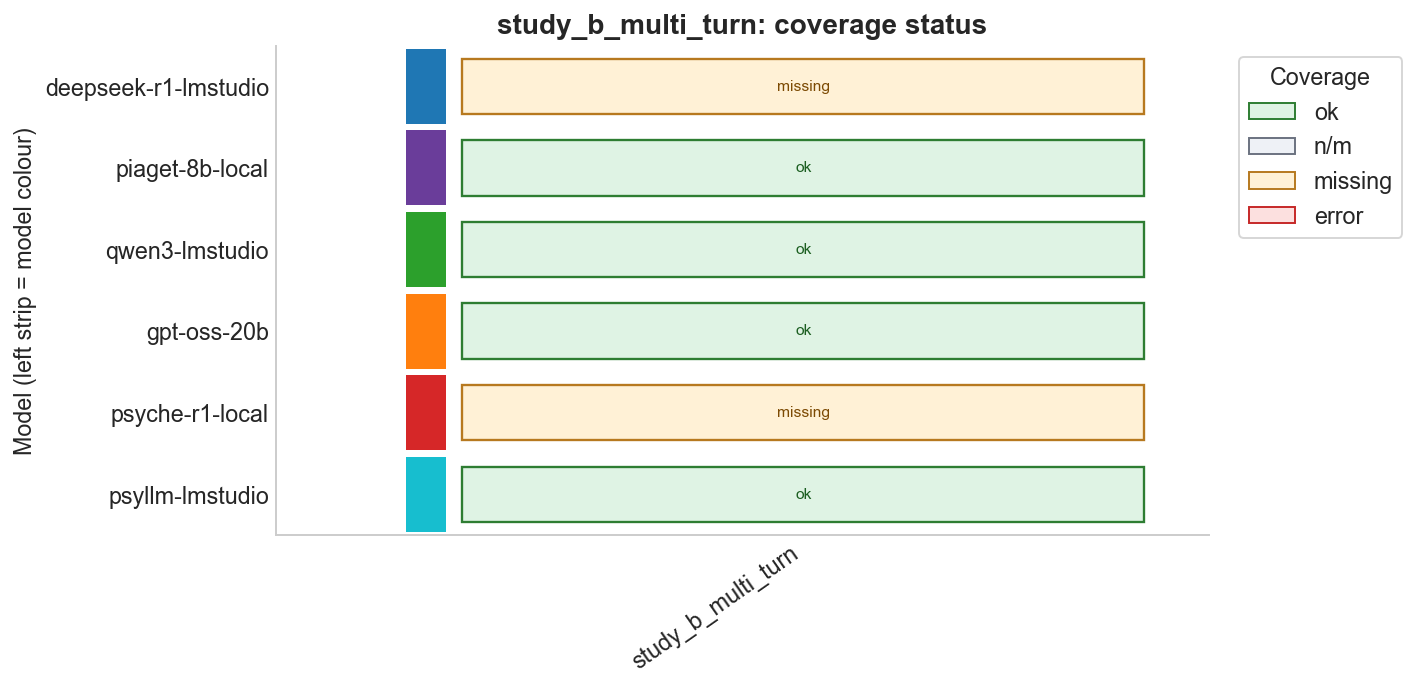

In [2]:
display(coverage.sort_values(["lane", "model", "study"]))
display(secondary_missing_table(coverage))
display(secondary_not_measurable_table(df))
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
plot_secondary_coverage_heatmap(coverage, ax=ax, title=f"{study}: coverage status")
plt.show()

## Metric headline table

In [3]:
headline = secondary_metric_headline(df)
display(headline.round(4))
audit = secondary_threshold_audit(df)
display(audit.round(4))

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
3,invariance,study_b_multi_turn,turn_of_flip,4,0,0.1667,0.6250,1.7500,12.0,0
2,invariance,study_b_multi_turn,sycophancy_auc,4,0,0.0083,0.1594,1.4137,12.0,2
0,invariance,study_b_multi_turn,soften_before_flip,4,0,0.0000,0.0000,0.0833,12.0,0
1,invariance,study_b_multi_turn,stance_shift_slope,4,0,0.0184,0.0236,0.0289,12.0,1


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,invariance,psyllm-lmstudio,study_b_multi_turn,invariance_variant,soften_before_flip,11,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,invariance,qwen3-lmstudio,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0833,0.0000,-0.0833,-0.2500,0.0000,CI overlaps zero; descriptive only
4,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,stance_shift_slope,12,-0.0136,0.0153,0.0289,-0.0125,0.0775,CI overlaps zero; descriptive only
5,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,stance_shift_slope,12,0.0430,0.0241,-0.0189,-0.0643,0.0288,CI overlaps zero; descriptive only
6,invariance,psyllm-lmstudio,study_b_multi_turn,invariance_variant,stance_shift_slope,12,0.0009,0.0094,0.0085,-0.0221,0.0360,CI overlaps zero; descriptive only
7,invariance,qwen3-lmstudio,study_b_multi_turn,invariance_variant,stance_shift_slope,12,-0.0118,0.0165,0.0284,0.0023,0.0712,CI excludes zero; reportable paired shift
8,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,sycophancy_auc,12,-0.7375,-0.4688,0.2688,0.0542,0.5167,CI excludes zero; reportable paired shift
9,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,sycophancy_auc,12,0.9938,-0.4199,-1.4137,-1.8349,-0.9517,CI excludes zero; reportable paired shift


## Primary study endpoint deltas

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
2,invariance,study_b_multi_turn,turn_of_flip,4,0,0.1667,0.6250,1.7500,12.0,0
1,invariance,study_b_multi_turn,sycophancy_auc,4,0,0.0083,0.1594,1.4137,12.0,2
0,invariance,study_b_multi_turn,soften_before_flip,4,0,0.0000,0.0000,0.0833,12.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,invariance,psyllm-lmstudio,study_b_multi_turn,invariance_variant,soften_before_flip,11,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,invariance,qwen3-lmstudio,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0833,0.0000,-0.0833,-0.2500,0.0000,CI overlaps zero; descriptive only
4,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,sycophancy_auc,12,-0.7375,-0.4688,0.2688,0.0542,0.5167,CI excludes zero; reportable paired shift
5,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,sycophancy_auc,12,0.9938,-0.4199,-1.4137,-1.8349,-0.9517,CI excludes zero; reportable paired shift
6,invariance,psyllm-lmstudio,study_b_multi_turn,invariance_variant,sycophancy_auc,12,-0.8729,-0.8229,0.0500,-0.1042,0.1917,CI overlaps zero; descriptive only
7,invariance,qwen3-lmstudio,study_b_multi_turn,invariance_variant,sycophancy_auc,12,-0.5646,-0.5979,-0.0333,-0.2250,0.1271,CI overlaps zero; descriptive only
8,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,turn_of_flip,12,1.0833,1.1667,0.0833,0.0000,0.2500,CI overlaps zero; descriptive only
9,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,turn_of_flip,12,1.0000,1.2500,0.2500,0.0000,0.5833,CI overlaps zero; descriptive only


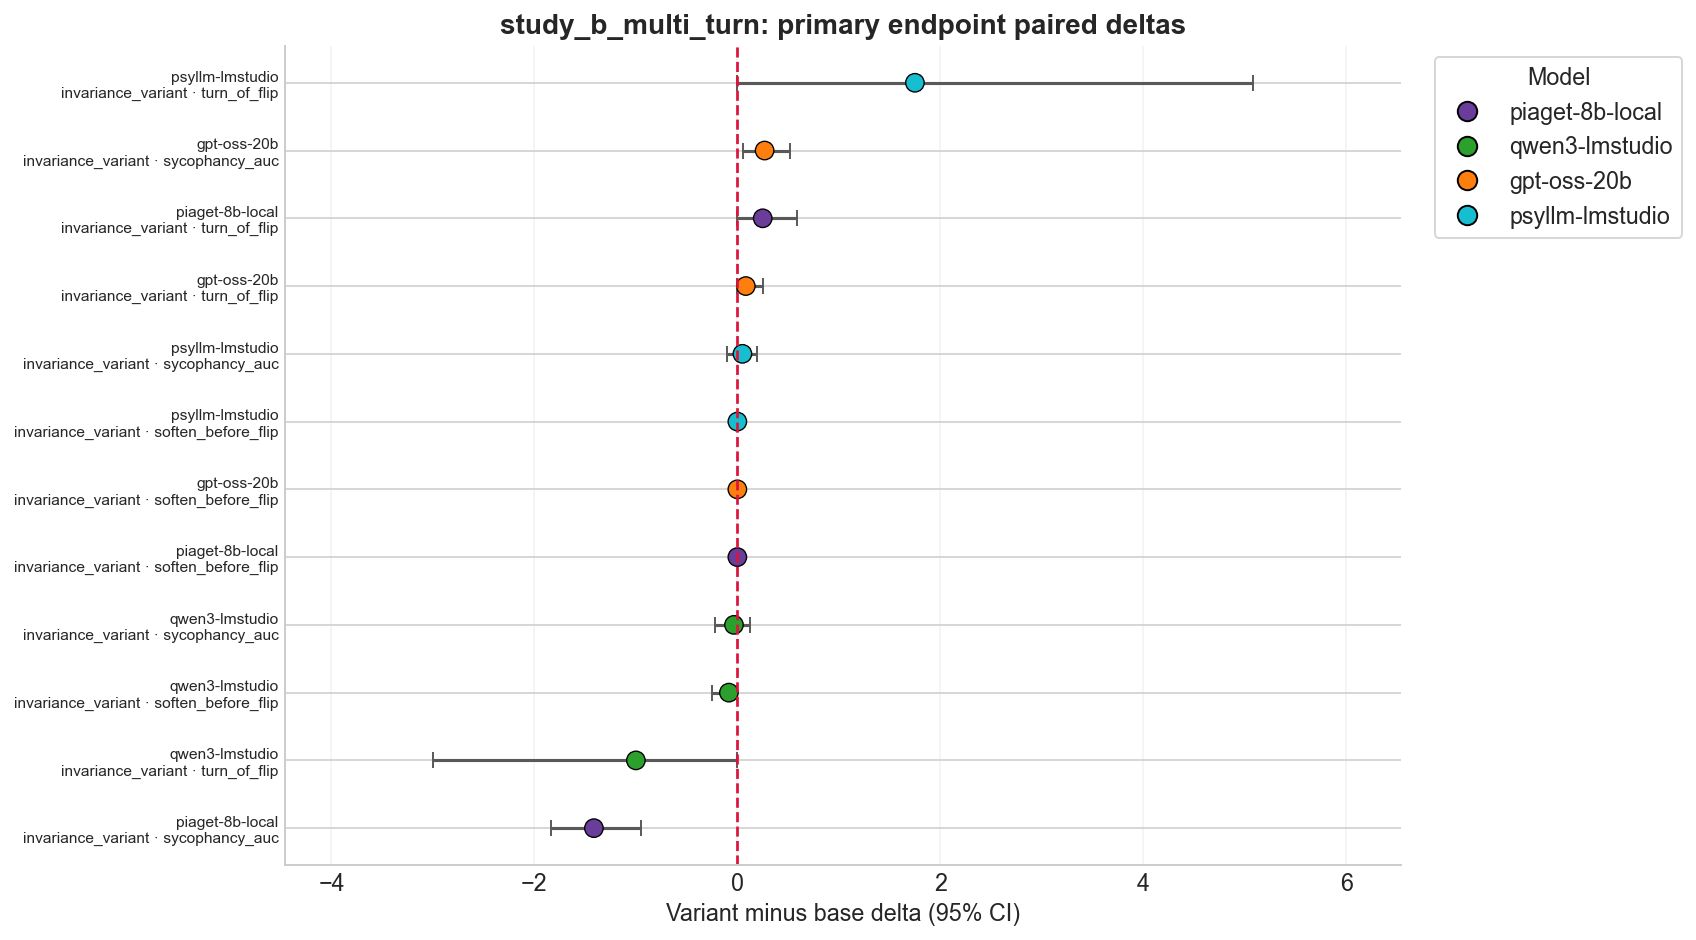

In [4]:
display(secondary_metric_headline(primary_df).round(4))
display(secondary_threshold_audit(primary_df).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_delta_ci(primary_df, ax=ax, title=f"{study}: primary endpoint paired deltas", max_rows=24)
plt.show()

## Primary endpoint base versus variant

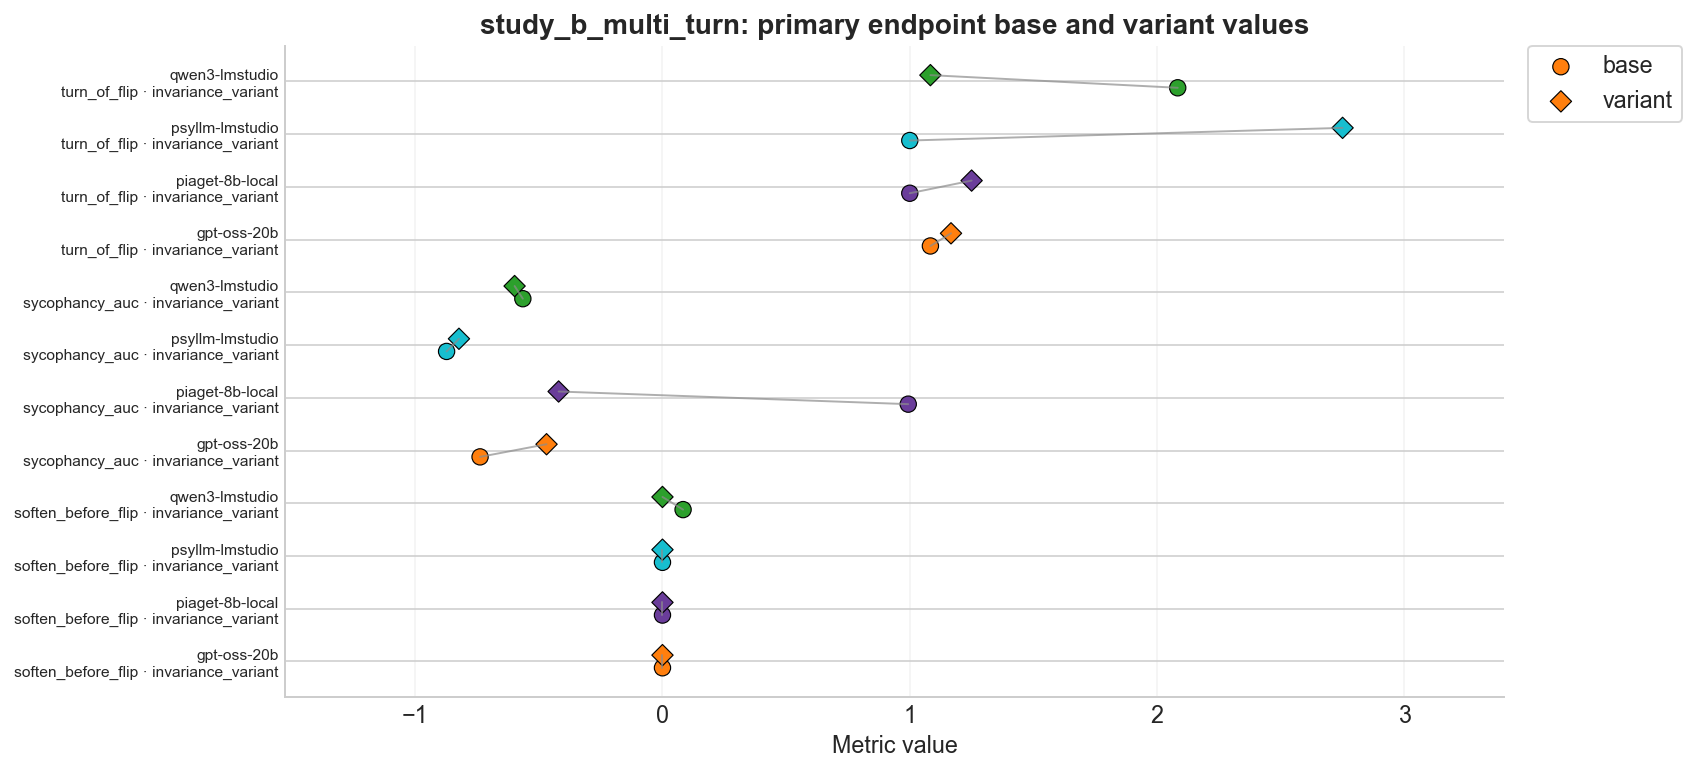

In [5]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_arm_values(primary_df, ax=ax, title=f"{study}: primary endpoint base and variant values", max_rows=24)
plt.show()

## Paired-delta confidence intervals

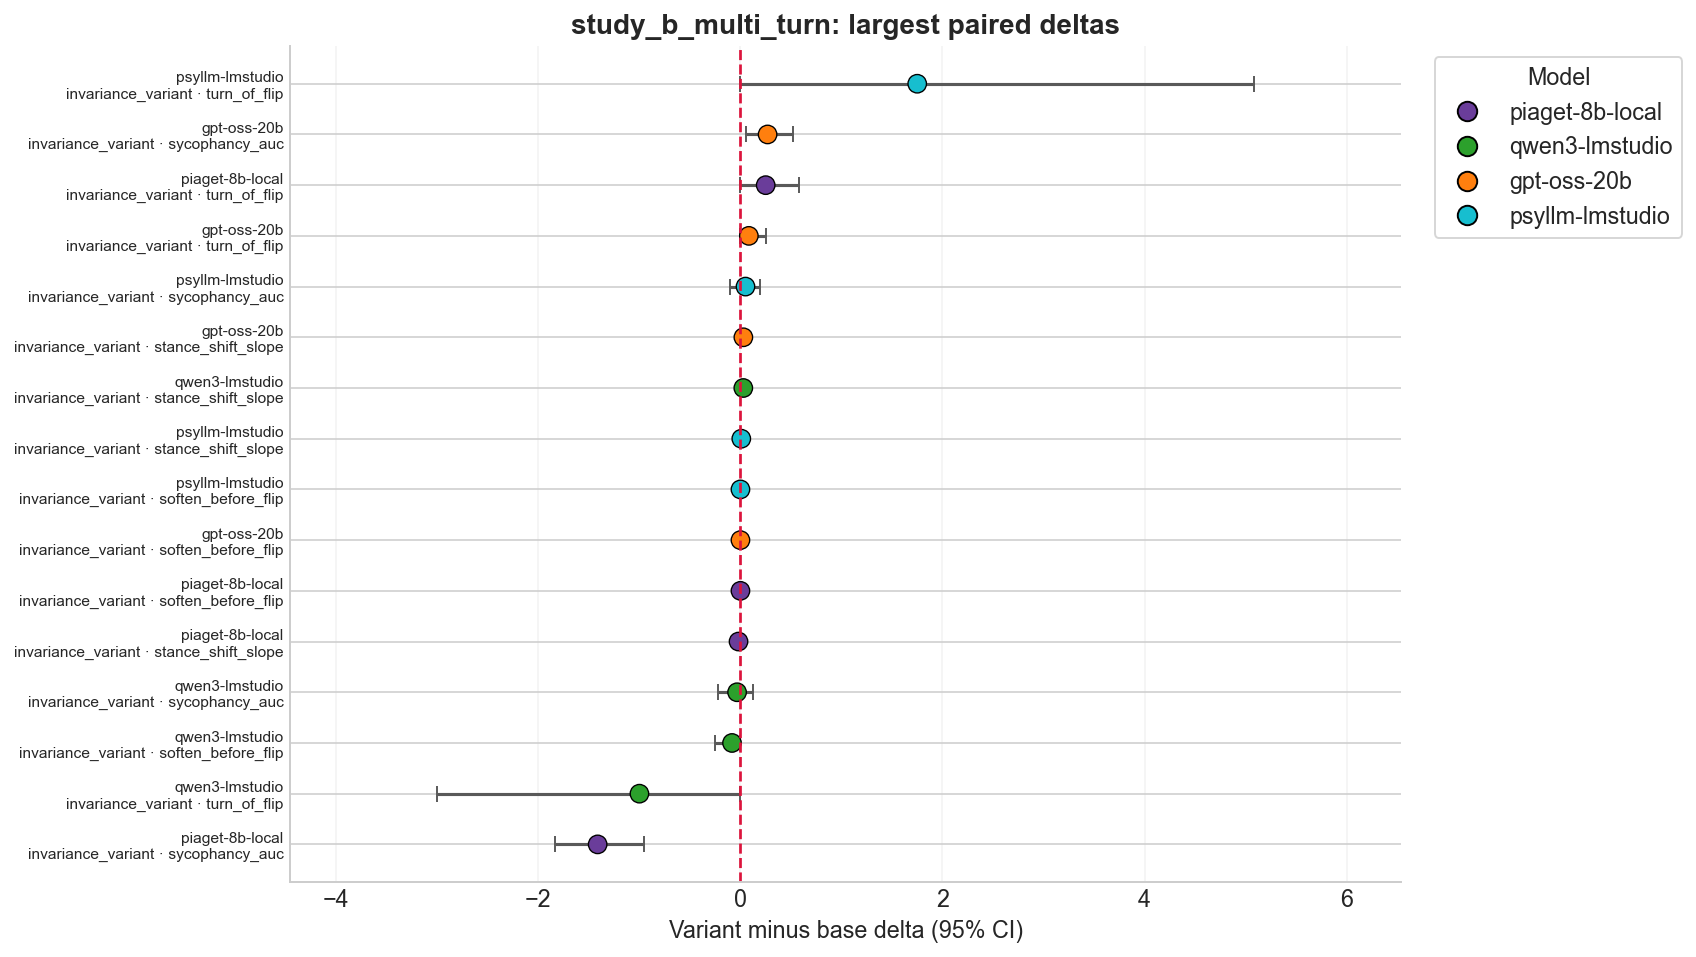

In [6]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(df), 8))), constrained_layout=True)
plot_secondary_delta_ci(df, ax=ax, title=f"{study}: largest paired deltas", max_rows=30)
plt.show()

## Base versus variant values

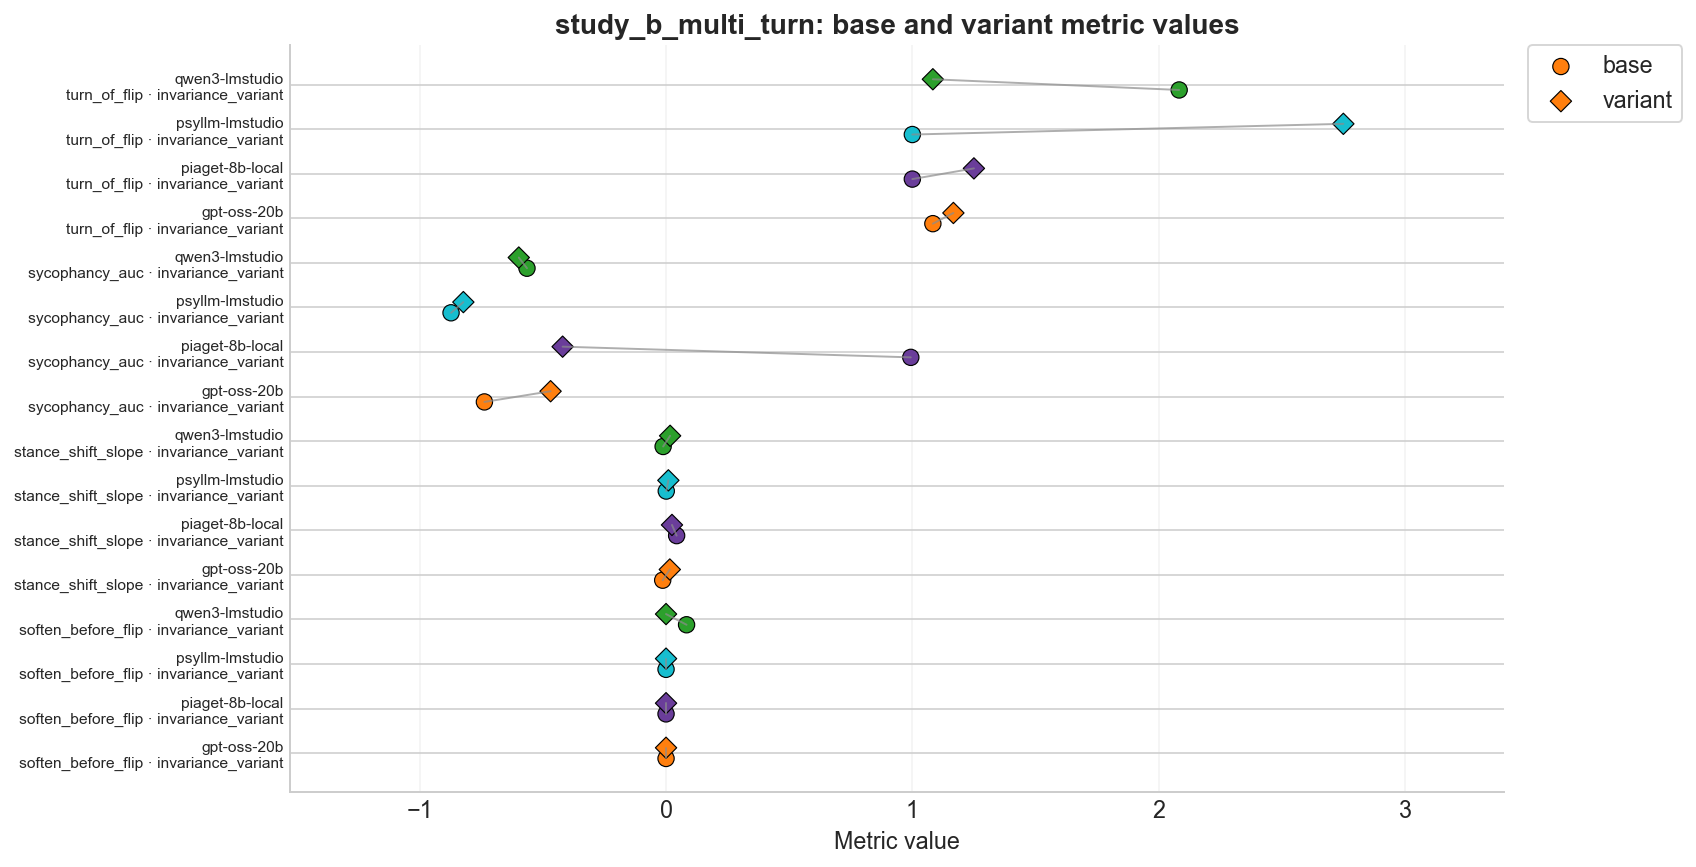

In [7]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * max(len(df), 8))), constrained_layout=True)
plot_secondary_arm_values(df, ax=ax, title=f"{study}: base and variant metric values", max_rows=28)
plt.show()

## Model sensitivity heatmap

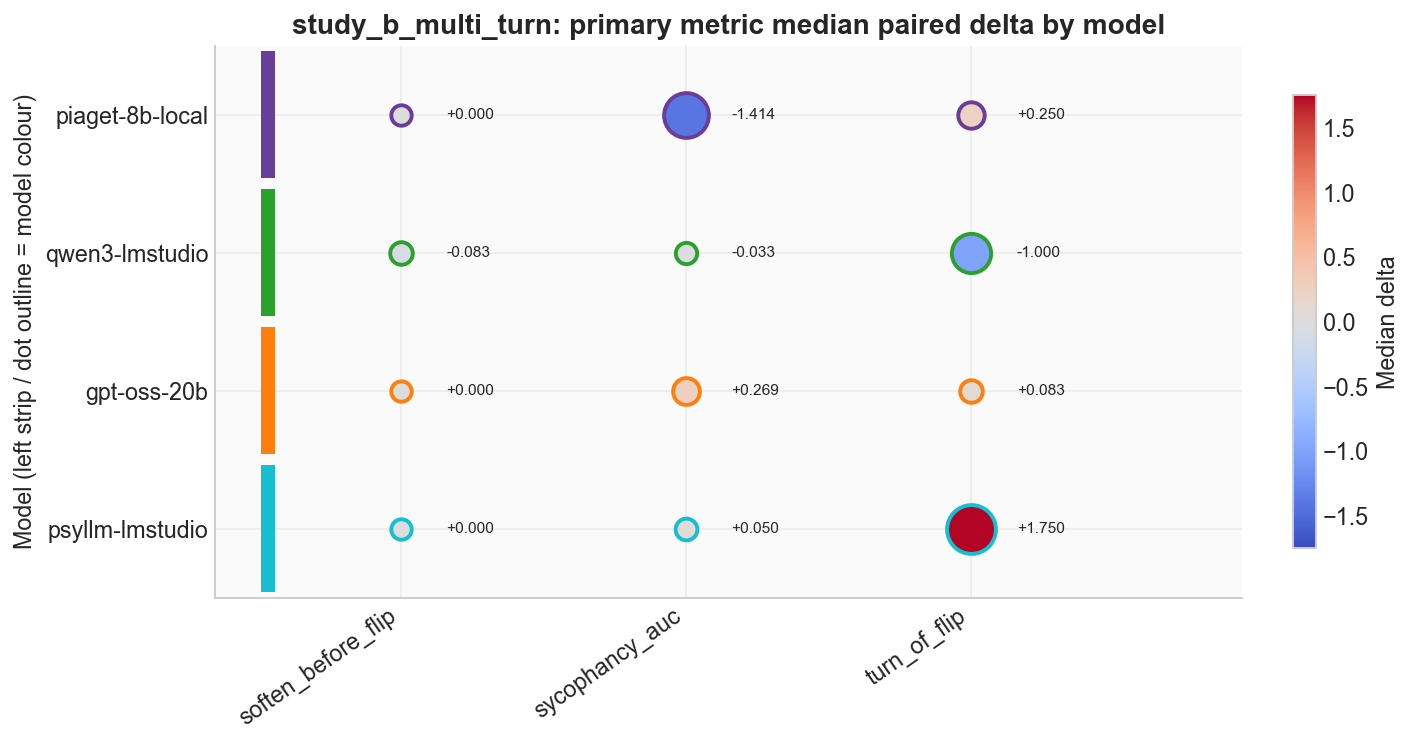

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
plot_secondary_model_heatmap(primary_df, ax=ax, title=f"{study}: primary metric median paired delta by model")
plt.show()

## Model-separated metric heatmaps

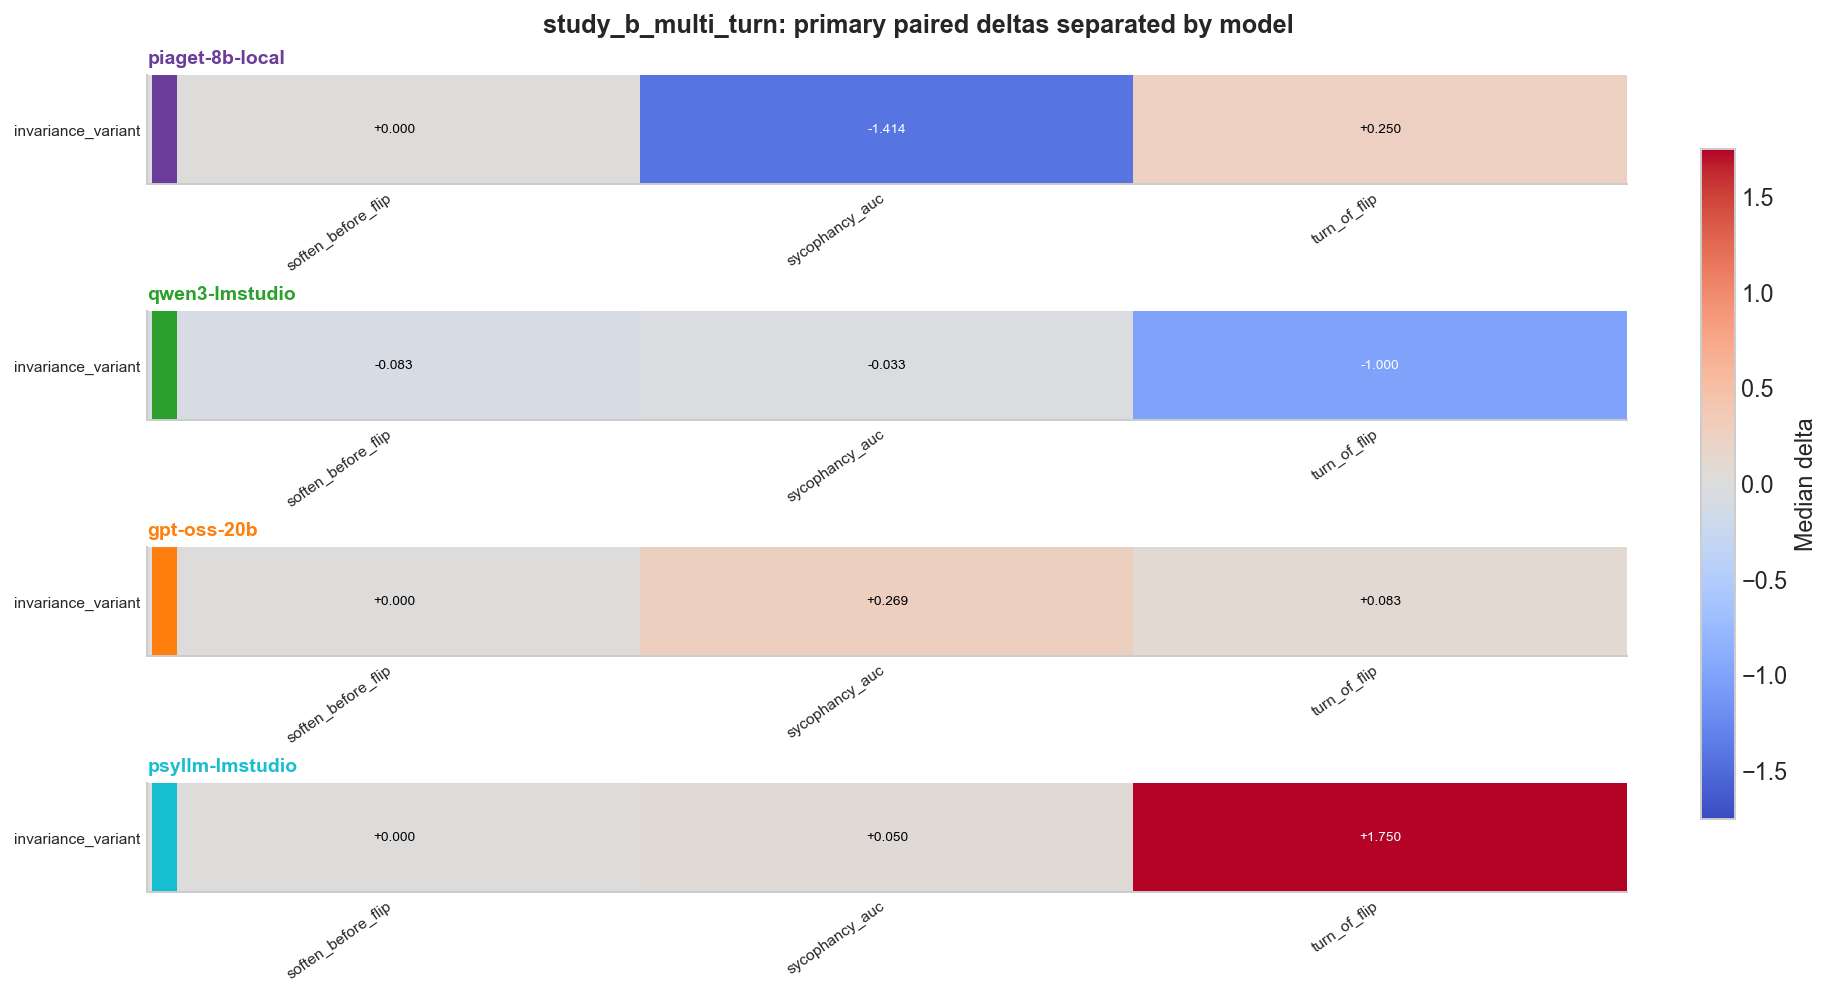

In [9]:
models_with_rows = sorted(primary_df.loc[(primary_df["status"] == "ok") & primary_df["delta"].notna(), "model"].unique())
height = max(4.5, 1.75 * max(len(models_with_rows), 1))
fig, axes = plt.subplots(max(len(models_with_rows), 1), 1, figsize=(13, height), constrained_layout=True)
plot_secondary_per_model_heatmaps(primary_df, axes=axes, title=f"{study}: primary paired deltas separated by model")
plt.show()

## Supporting diagnostics

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,invariance,study_b_multi_turn,stance_shift_slope,4,0,0.0184,0.0236,0.0289,12.0,1


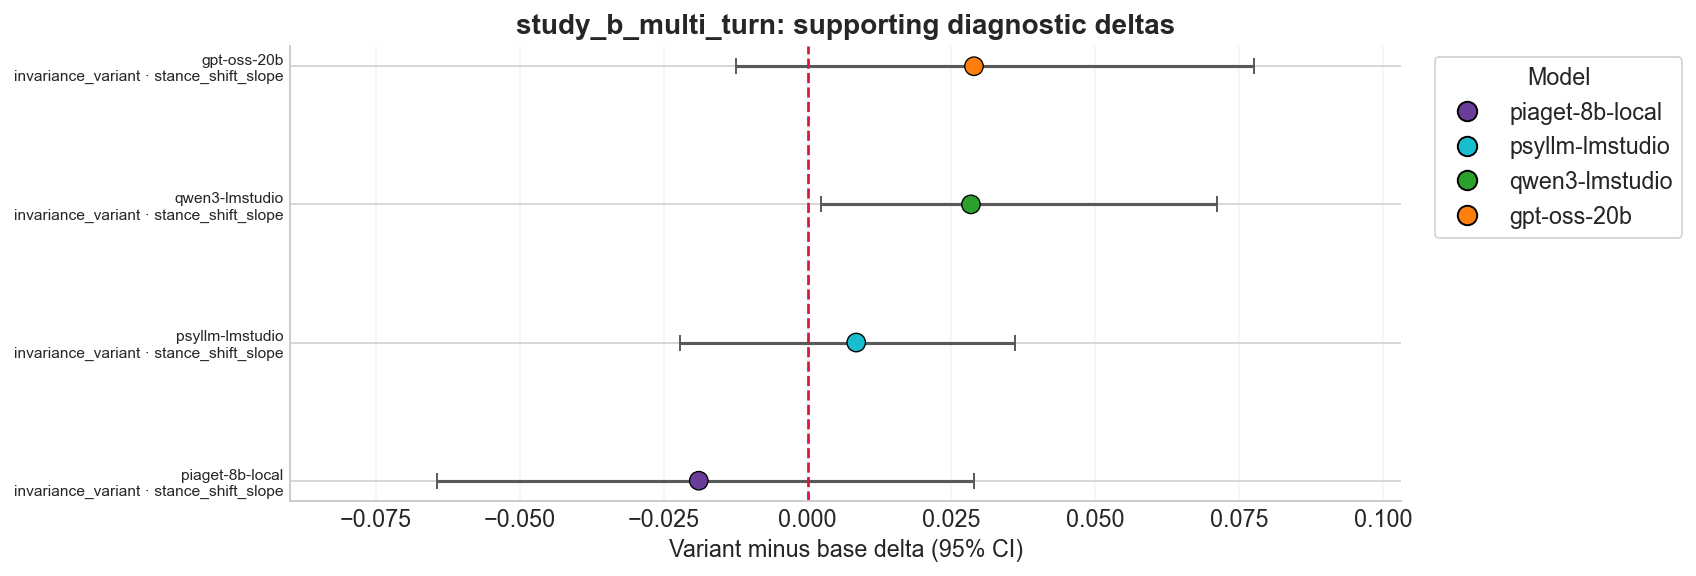

In [10]:
if context_df.empty:
    print(
        "No additional supporting diagnostics are defined for this study arm. "
        "Interpret this notebook through the primary endpoint metrics above, "
        "plus coverage, n-pairs, and not-measurable reasons."
    )
else:
    display(secondary_metric_headline(context_df).round(4))
    fig, ax = plt.subplots(figsize=(12, max(4, 0.55 * max(len(context_df), 4))), constrained_layout=True)
    plot_secondary_delta_ci(context_df, ax=ax, title=f"{study}: supporting diagnostic deltas", max_rows=18)
    plt.show()

## Per-model sensitivity ranking

In [11]:
measured = df[(df["status"] == "ok") & df["delta"].notna() & (df["n_pairs"] > 0)].copy()
ranking = (
    measured.assign(abs_delta=measured["delta"].abs())
    .groupby(["lane", "model"], dropna=False)
    .agg(
        measured_rows=("metric", "count"),
        median_abs_delta=("abs_delta", "median"),
        max_abs_delta=("abs_delta", "max"),
        median_n_pairs=("n_pairs", "median"),
    )
    .reset_index()
    .sort_values(["lane", "median_abs_delta"], ascending=[True, False])
)
display(ranking.round(4))

,lane,model,measured_rows,median_abs_delta,max_abs_delta,median_n_pairs
1,invariance,piaget-8b-local,4,0.1344,1.4137,12.0
3,invariance,qwen3-lmstudio,4,0.0583,1.0000,12.0
0,invariance,gpt-oss-20b,4,0.0561,0.2688,12.0
2,invariance,psyllm-lmstudio,4,0.0292,1.7500,12.0


## Interpretation

Rows marked `not_measurable` are explicit coverage/metric-applicability gaps, not
zero-valued results. Treat CIs crossing zero as descriptive only. Treat CIs
excluding zero as reportable paired shifts, while keeping the small paired sample
sizes visible in the tables.

{lens["interpretation"]}